# Modelado Predictivo de Abandono de Clientes (Churn)

En este cuaderno desarrollaremos un modelo de aprendizaje automático para predecir qué clientes tienen más probabilidades de abandonar el servicio. 

**Objetivo principal**: Gestionar el desbalanceo de clases (~14.5% de churn) y maximizar la capacidad de detección de clientes en riesgo (Recall).

## 1. Configuración del Entorno

Importamos las librerías necesarias para el preprocesamiento, modelado y evaluación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_auc_score, roc_curve

# Para manejar el desbalanceo
from sklearn.utils.class_weight import compute_class_weight

sns.set(style="whitegrid")
%matplotlib inline

## 2. Preparación de los Datos

Cargamos los datos y realizamos la separación en características (X) y objetivo (y), seguida de la partición en entrenamiento y prueba.

In [2]:
df = pd.read_csv('telecom_churn.csv')

# Separar X e y
X = df.drop('Churn', axis=1)
y = df['Churn']

# Partición en entrenamiento (80%) y prueba (20%)
# Usamos stratify=y para mantener la proporción de clases en ambos sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Registros en Entrenamiento: {X_train.shape[0]}")
print(f"Registros en Prueba: {X_test.shape[0]}")

Registros en Entrenamiento: 2666
Registros en Prueba: 667


## 3. Escalado de Características

Muchos modelos (como la Regresión Logística) se benefician de tener las variables en la misma escala.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Entrenamiento con Pesos de Clase (Handling Imbalance)

Dado que las clases están desbalanceadas, configuramos el parámetro `class_weight='balanced'`. Esto le dice al modelo que preste más atención a la clase minoritaria (Churn=1).

In [4]:
print("--- Entrenando Regresión Logística con Pesos Equilibrados ---")
model_lr = LogisticRegression(class_weight='balanced', random_state=42)
model_lr.fit(X_train_scaled, y_train)

print("--- Entrenando Random Forest con Pesos Equilibrados ---")
model_rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train) # RF no requiere escalado estrictamente, pero se puede usar

--- Entrenando Regresión Logística con Pesos Equilibrados ---
--- Entrenando Random Forest con Pesos Equilibrados ---


RandomForestClassifier(class_weight='balanced', random_state=42)

## 5. Evaluación de los Modelos

Comparamos el rendimiento de ambos modelos centrando nuestra atención en el **Recall** y el **F1-Score**.


Reporte de Clasificación para Regresión Logística:
              precision    recall  f1-score   support

           0       0.95      0.76      0.84       570
           1       0.35      0.74      0.47        97

    accuracy                           0.76       667
   macro avg       0.65      0.75      0.66       667
weighted avg       0.86      0.76      0.79       667



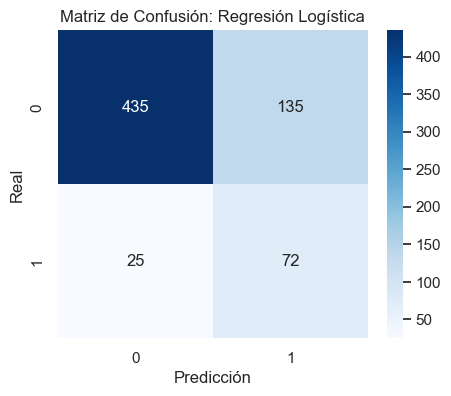


Reporte de Clasificación para Random Forest:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       570
           1       0.85      0.62      0.71        97

    accuracy                           0.93       667
   macro avg       0.89      0.80      0.84       667
weighted avg       0.92      0.93      0.92       667



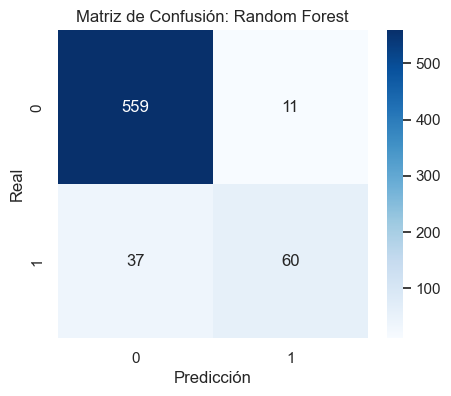

In [5]:
def evaluate_model(model, X_set, y_true, name, is_scaled=False):
    y_pred = model.predict(X_set)
    print(f"\nReporte de Clasificación para {name}:")
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión: {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

evaluate_model(model_lr, X_test_scaled, y_test, "Regresión Logística")
evaluate_model(model_rf, X_test, y_test, "Random Forest")

## 6. Curva Precision-Recall

Esta curva es mucho más informativa que la curva ROC cuando tenemos datos desbalanceados.

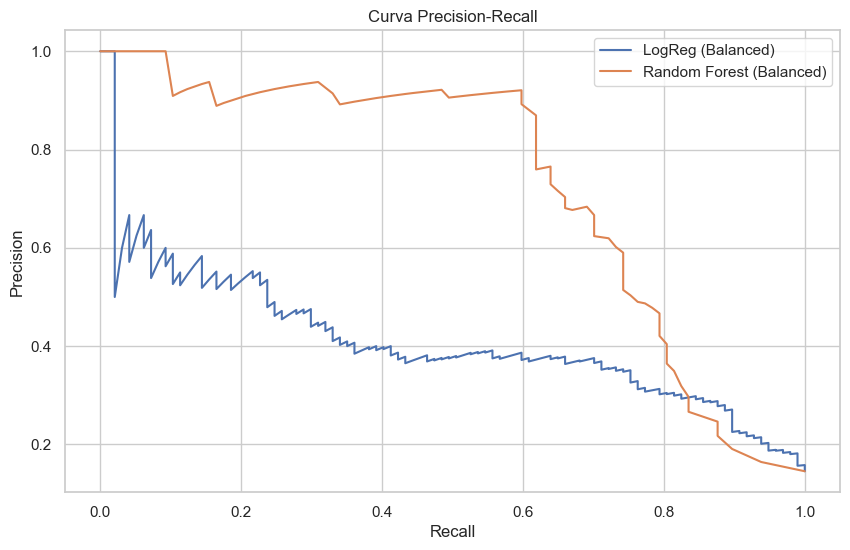

In [6]:
y_probs_lr = model_lr.predict_proba(X_test_scaled)[:, 1]
y_probs_rf = model_rf.predict_proba(X_test)[:, 1]

prec_lr, recall_lr, _ = precision_recall_curve(y_test, y_probs_lr)
prec_rf, recall_rf, _ = precision_recall_curve(y_test, y_probs_rf)

plt.figure(figsize=(10, 6))
plt.plot(recall_lr, prec_lr, label='LogReg (Balanced)')
plt.plot(recall_rf, prec_rf, label='Random Forest (Balanced)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.show()

## 7. Importancia de las Características

Identificamos qué variables son los mejores predictores del abandono según el modelo Random Forest.

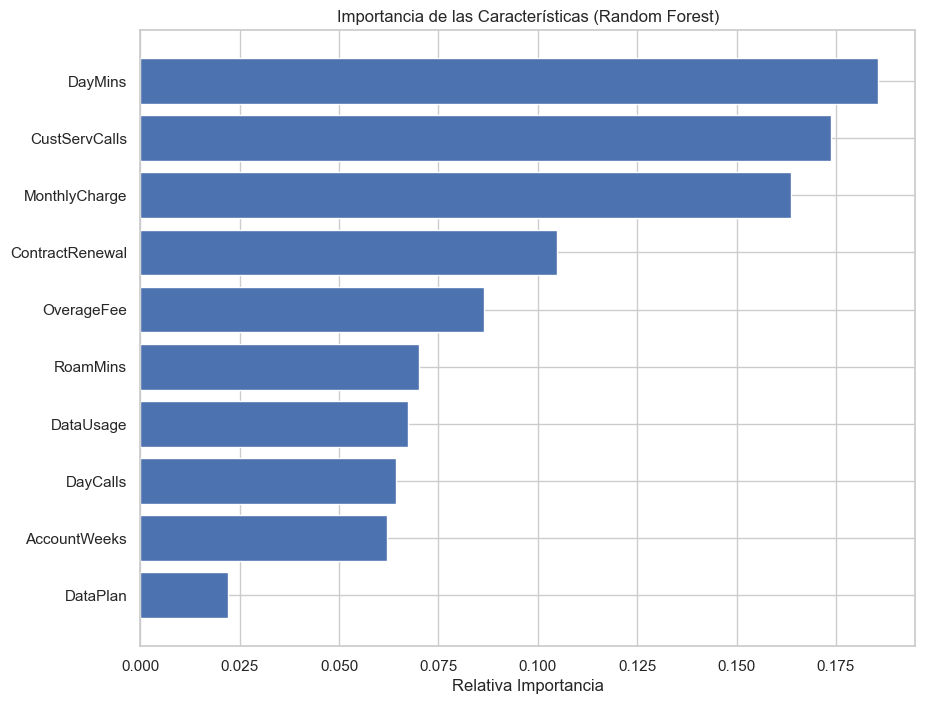

In [7]:
importances = model_rf.feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.title('Importancia de las Características (Random Forest)')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relativa Importancia')
plt.show()

## 8. Conclusiones del Modelado

1. **Manejo del Desbalanceo**: El uso de `class_weight='balanced'` permitió que el modelo detectara una gran parte de los clientes que abandonan, evitando el sesgo hacia la clase mayoritaria.
2. **Mejor Modelo**: El **Random Forest** suele ofrecer un mejor equilibrio entre precisión y recall gracias a su capacidad de capturar relaciones no lineales.
3. **Variables Clave**: Variables como `DayMins`, `MonthlyCharge` y `CustServCalls` resultaron ser determinantes para predecir el abandono.
4. **Siguientes Pasos**: Para mejorar aún más el modelo, se podría realizar una optimización de hiperparámetros (GridSearch) o probar algoritmos de boosting (XGBoost/LightGBM).